# Data Understanding
---

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

✅ Library berhasil diimport.


In [20]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

## Load Dataset

In [21]:
DATA_PATH = 'ulasan_bummitani.csv'

df = pd.read_csv(DATA_PATH)

print(f'   → Jumlah baris  : {df.shape[0]}')
print(f'   → Jumlah kolom  : {df.shape[1]}')
print(f'   → Nama kolom    : {list(df.columns)}')

   → Jumlah baris  : 499
   → Jumlah kolom  : 6
   → Nama kolom    : ['No', 'Username', 'Rating', 'Waktu', 'Ulasan Text', 'Variasi']


## Tampilan Awal Data

In [22]:
df.head(5)

,No,Username,Rating,Waktu,Ulasan Text,Variasi
0,1,t*****a,5,2022-08-28 16:48,"Kualitas: bagus Cocok Untuk: boluu Nyampenya cepet, setelah dieksekusi hasilnya memuaskan, enak bgt bolunya, pas mat...",-
1,2,t*****9,5,2022-03-17 19:32,Jenis: tepung ketan hitam Harga: murah Kualitas: bagus Pertama kali beli tepung ini buat bikin bolu ketan pas lebara...,-
2,3,a*****2,5,2025-07-07 20:01,Rasa: enak Tekstur: normal seperti tepung ketan pada umumnya Kegunaan: cocok untuk membuat kue Solusi jitu biar ga b...,-
3,4,nienieng,5,2025-06-06 19:08,Rasa: enak dibuat bolu Kegunaan: buat bolu ketan hitam ORI dan keju lumer Kualitas: baik Pake tepung ini hitamnya pe...,-
4,5,Langganan,5,2022-02-05 10:19,Jenis: tepung ketan hitam Harga: murah Kualitas: ok Yuk bantu UMKM kita maju dengan berbelanja di toko ini. Pengemas...,-


In [23]:
df.tail(5)

,No,Username,Rating,Waktu,Ulasan Text,Variasi
494,495,t*****7,5,2025-07-03 22:12,Baru mau coba,-
495,496,mutiaraayudia.s04,5,2025-07-02 17:33,Belum dicoba 🙏,-
496,497,khusnulmawwan,5,2025-06-29 17:40,Belum dicoba.kalau sesuai nanti order lagi,-
497,498,linaemran20014,5,2025-06-28 14:22,Rasa: belum coba,-
498,499,hijrotunnadia,5,2025-06-15 16:23,Siap di eksekusi,-


## Informasi Struktur Data

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   No           499 non-null    int64
 1   Username     499 non-null    str  
 2   Rating       499 non-null    int64
 3   Waktu        499 non-null    str  
 4   Ulasan Text  499 non-null    str  
 5   Variasi      499 non-null    str  
dtypes: int64(2), str(4)
memory usage: 23.5 KB


In [25]:
df.describe(include='all')

,No,Username,Rating,Waktu,Ulasan Text,Variasi
count,499.000000,499,499.000000,499,499,499
unique,NaN,394,NaN,490,493,1
top,NaN,Langganan,NaN,2022-06-06 17:15,"Tekstur: lembut Rasa: enak Alhamdulillah paket sdh sampai, pengiriman cpt, packing rapih, hrga oke & barangnya realp...",-
freq,NaN,15,NaN,2,4,499
mean,250.000000,NaN,4.995992,NaN,NaN,NaN
std,144.193157,NaN,0.089532,NaN,NaN,NaN
min,1.000000,NaN,3.000000,NaN,NaN,NaN
25%,125.500000,NaN,5.000000,NaN,NaN,NaN
50%,250.000000,NaN,5.000000,NaN,NaN,NaN
75%,374.500000,NaN,5.000000,NaN,NaN,NaN


## Pengecekan Missing Values

In [26]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

             Jumlah Missing  Persentase (%)
No                        0             0.0
Username                  0             0.0
Rating                    0             0.0
Waktu                     0             0.0
Ulasan Text               0             0.0
Variasi                   0             0.0

Total missing values: 0


Tidak ada missing values


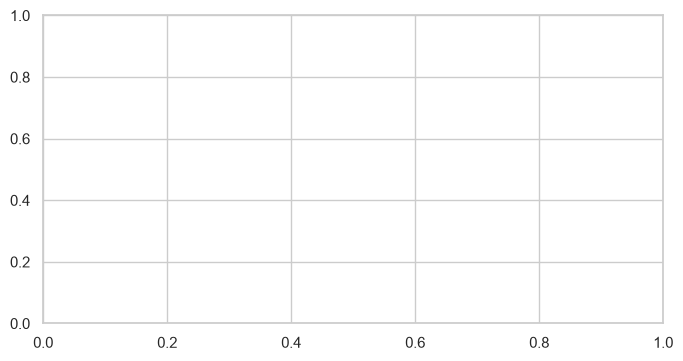

In [28]:
# Visualisasi Missing Values
fig, ax = plt.subplots(figsize=(8, 4))
missing_plot = missing_pct[missing_pct > 0]
if len(missing_plot) > 0:
    missing_plot.plot(kind='barh', color='#E74C3C', ax=ax, edgecolor='white')
    ax.set_title('Persentase Missing Values per Kolom', fontsize=13, fontweight='bold')
    ax.set_xlabel('Persentase (%)')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ada missing values')

## Pengecekan Duplikat

In [30]:
n_duplikat = df.duplicated().sum()
n_duplikat_ulasan = df.duplicated(subset=['Ulasan Text']).sum()

print(f'Duplikat seluruh baris      : {n_duplikat}')
print(f'Duplikat kolom Ulasan Text  : {n_duplikat_ulasan}')

if n_duplikat_ulasan > 0:
    print('Ulasan yang Duplikat')
    print(df[df.duplicated(subset=['Ulasan Text'], keep=False)][['Username', 'Ulasan Text']].head(6))

Duplikat seluruh baris      : 0
Duplikat kolom Ulasan Text  : 6
Ulasan yang Duplikat
           Username  \
103     wetriyputri   
123       franiko88   
127     wetriyputri   
222  suharti12april   
223  suharti12april   
269  leniprastyanii   

                                                                                                                 Ulasan Text  
103                               Desain sangat menanrik dan bagus, ukuran pas dan sesuai, kualitas bagus dan memuaskan 0:04  
123                                                         Makasih shopee buat diskonnya jadi bisa beli barang ini deh 0:04  
127                               Desain sangat menanrik dan bagus, ukuran pas dan sesuai, kualitas bagus dan memuaskan 0:04  
222         Terimakasih banyak atas pengirimannya 👍👍 semoga semakin bertambah sukses laris manis dan berkah usahanya, aamiin  
223         Terimakasih banyak atas pengirimannya 👍👍 semoga semakin bertambah sukses laris manis dan berkah usahanya, 

## Distribusi Rating Bintang

In [31]:
rating_dist = df['Rating'].value_counts().sort_index()
print(rating_dist)
print(f'\nRating rata-rata: {df["Rating"].mean():.2f}')

Rating
3      1
5    498
Name: count, dtype: int64

Rating rata-rata: 5.00


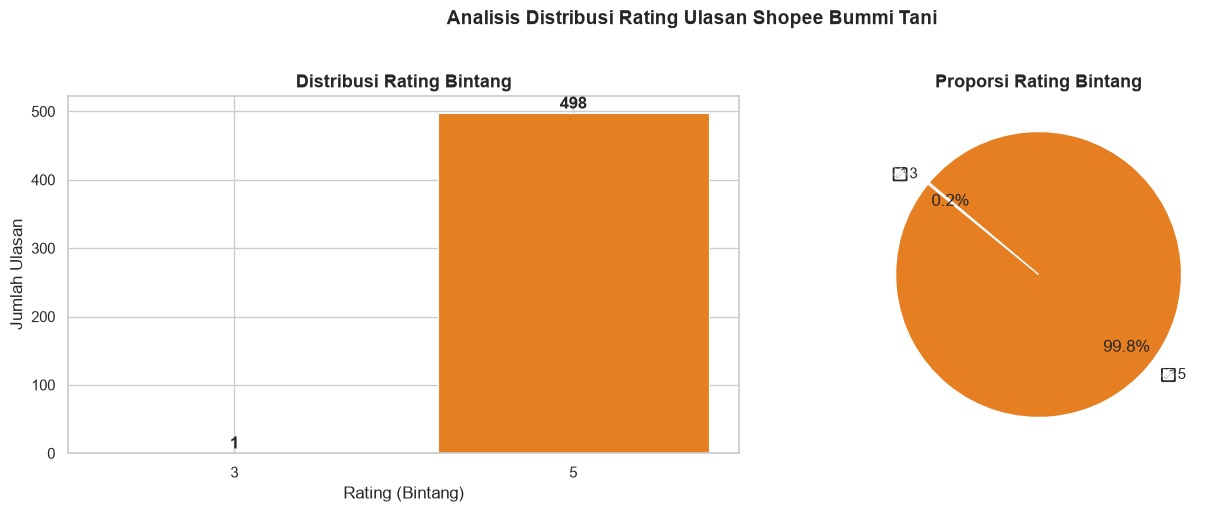

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart Distribusi Rating
colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#27AE60']
bars = axes[0].bar(rating_dist.index.astype(str), rating_dist.values,
                   color=colors[:len(rating_dist)], edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribusi Rating Bintang', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating (Bintang)')
axes[0].set_ylabel('Jumlah Ulasan')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 1, f'{int(h)}',
                 ha='center', va='bottom', fontweight='bold')

# Pie Chart
wedge_colors = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#27AE60']
axes[1].pie(rating_dist.values, labels=[f'⭐{i}' for i in rating_dist.index],
            autopct='%1.1f%%', colors=wedge_colors[:len(rating_dist)],
            startangle=140, pctdistance=0.8)
axes[1].set_title('Proporsi Rating Bintang', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Distribusi Rating Ulasan Shopee Bummi Tani',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Analisis Teks Ulasan

In [34]:
df_clean_view = df.dropna(subset=['Ulasan Text']).copy()
df_clean_view['panjang_karakter'] = df_clean_view['Ulasan Text'].astype(str).apply(len)
df_clean_view['jumlah_kata'] = df_clean_view['Ulasan Text'].astype(str).apply(lambda x: len(x.split()))

print(df_clean_view[['panjang_karakter', 'jumlah_kata']].describe().round(2))

       panjang_karakter  jumlah_kata
count             499.0       499.00
mean              119.2        18.99
std                72.8        11.66
min                 4.0         1.00
25%                70.0        11.00
50%               106.0        17.00
75%               151.5        24.00
max               527.0        79.00


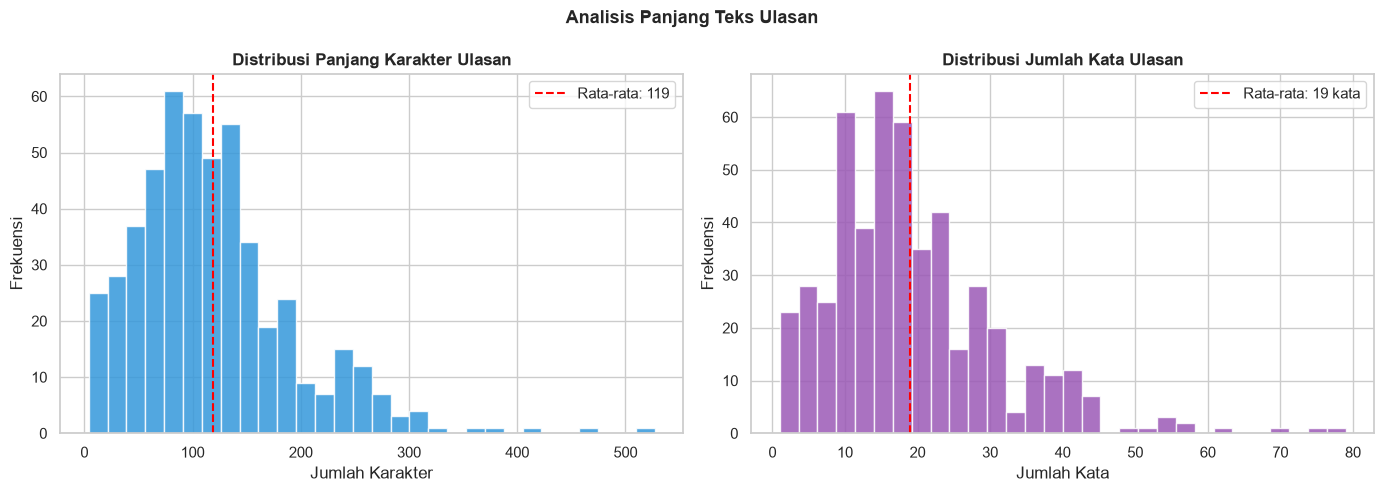

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi panjang karakter
axes[0].hist(df_clean_view['panjang_karakter'], bins=30, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean_view['panjang_karakter'].mean(), color='red', linestyle='--',
                label=f"Rata-rata: {df_clean_view['panjang_karakter'].mean():.0f}")
axes[0].set_title('Distribusi Panjang Karakter Ulasan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Distribusi jumlah kata
axes[1].hist(df_clean_view['jumlah_kata'], bins=30, color='#9B59B6', edgecolor='white', alpha=0.85)
axes[1].axvline(df_clean_view['jumlah_kata'].mean(), color='red', linestyle='--',
                label=f"Rata-rata: {df_clean_view['jumlah_kata'].mean():.0f} kata")
axes[1].set_title('Distribusi Jumlah Kata Ulasan', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.suptitle('Analisis Panjang Teks Ulasan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribusi Ulasan Berdasarkan Waktu

In [16]:
df_time = df.copy()
df_time['Waktu'] = pd.to_datetime(df_time['Waktu'], errors='coerce')
df_time['Tahun'] = df_time['Waktu'].dt.year
df_time['Bulan'] = df_time['Waktu'].dt.month

tahun_dist = df_time['Tahun'].value_counts().sort_index()
print('=== Distribusi Ulasan per Tahun ===')
print(tahun_dist)

=== Distribusi Ulasan per Tahun ===
Tahun
2022     57
2023     15
2024      1
2025    380
2026     46
Name: count, dtype: int64


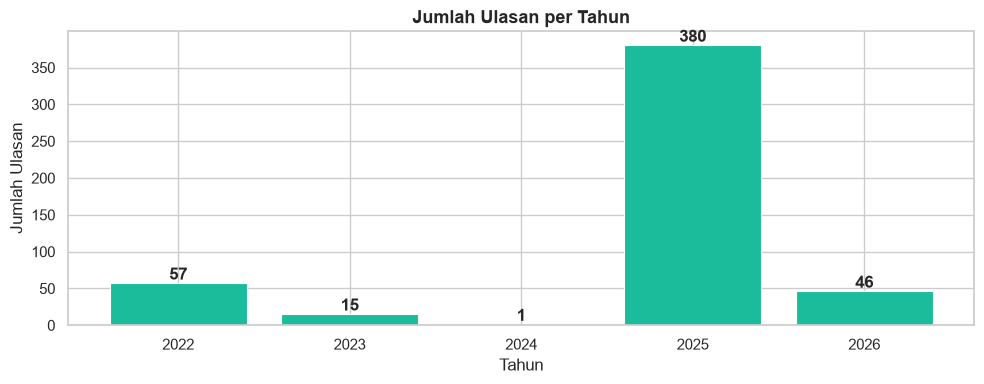

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(tahun_dist.index.astype(str), tahun_dist.values,
              color='#1ABC9C', edgecolor='white', linewidth=0.8)
ax.set_title('Jumlah Ulasan per Tahun', fontsize=13, fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('Jumlah Ulasan')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.3, str(int(h)),
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## Top Reviewer & Analisis Username

Top 10 Reviewer Paling Aktif
Username
Langganan         15
leniprastyanii     7
a*****2            5
a*****i            5
dwiriy19           4
a*****a            4
r*****s            4
aw389d478a         4
d*****4            4
nienieng           3
Name: count, dtype: int64


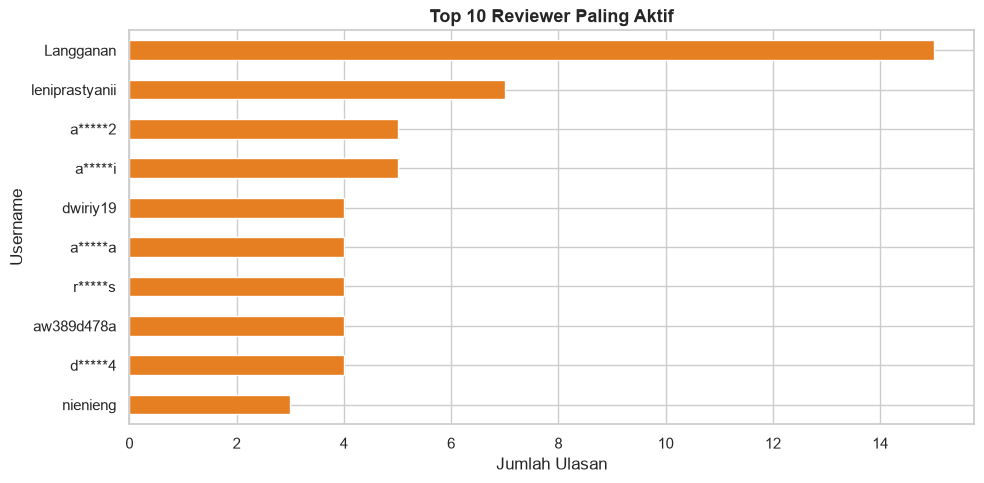

In [37]:
top_reviewer = df['Username'].value_counts().head(10)
print('Top 10 Reviewer Paling Aktif')
print(top_reviewer)

fig, ax = plt.subplots(figsize=(10, 5))
top_reviewer.plot(kind='barh', color='#E67E22', edgecolor='white', ax=ax)
ax.set_title('Top 10 Reviewer Paling Aktif', fontsize=13, fontweight='bold')
ax.set_xlabel('Jumlah Ulasan')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Contoh Ulasan Terpanjang & Terpendek

In [40]:
df_sorted_len = df_clean_view.sort_values('panjang_karakter', ascending=False)

print('Ulasan TERPANJANG')
print(df_sorted_len.iloc[0]['Ulasan Text'])
print(f"  → {df_sorted_len.iloc[0]['panjang_karakter']} karakter\n")

print('Ulasan TERPENDEK')
df_nonempty = df_clean_view[df_clean_view['panjang_karakter'] > 1].sort_values('panjang_karakter')
print(df_nonempty.iloc[0]['Ulasan Text'])
print(f"  → {df_nonempty.iloc[0]['panjang_karakter']} karakter")

Ulasan TERPANJANG
Tekstur: teksturnua lembut Rasa: rasa tepungnya enak dan harum Rasakan: benar enak, harum dan lembut Siangnya paket sampai langsung sorenya dieksekusi bikin bolu ketan hitam keju lumer. Setelah sekian purnama akhirnya ga penasaran lagi. Update Penilaian Siang paketnya sampai, sorenya langsung dieksekusi bikin bolu ketan hitam keju lumer setelah sekian purnama nyari2 tepung ketan hitam di daerah saya ga ada dan ternyata beneran seenak itu apalagi pakai tepung merk ini. Ga ada bau apeknya.. Murah lagi. Bakal langganan deh..
  → 527 karakter

Ulasan TERPENDEK
0:13
  → 4 karakter


## Ringkasan Data Understanding

| Aspek | Temuan |
|-------|--------|
| Total Data | 500 ulasan |
| Kolom Penting | `Ulasan Text`, `Rating`, `Waktu` |
| Missing Values | Perlu dicek (terutama kolom `Ulasan Text`) |
| Duplikat | Perlu dihapus di tahap Data Preparation |
| Distribusi Rating | Mayoritas bintang 5 (sangat tidak seimbang) |
| Panjang Teks | Bervariasi, ada yang sangat pendek dan sangat panjang |